# Restaurant Food Delivery - Exploratory Data Analysis
This notebook contains an end-to-end Exploratory Data Analysis (EDA) of a restaurant food delivery dataset. The analysis aims to uncover patterns in food costs, customer ratings, locations, and delivery times.

Importing Necessary Libraries


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style for nicer plots
%matplotlib inline
sns.set_theme(style="whitegrid")

# Load the dataset
df = pd.read_excel('Data_Train.xlsx')


### Data Inspection
Looking at the basic structure and shape of the dataset.


In [9]:
# Check shape and column names
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (11094, 9)
Columns: ['Restaurant', 'Location', 'Cuisines', 'Average_Cost', 'Minimum_Order', 'Rating', 'Votes', 'Reviews', 'Delivery_Time']


Checking the data types and look for any missing values.


In [10]:
# Display column summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11094 entries, 0 to 11093
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Restaurant     11094 non-null  object
 1   Location       11094 non-null  object
 2   Cuisines       11094 non-null  object
 3   Average_Cost   11094 non-null  object
 4   Minimum_Order  11094 non-null  object
 5   Rating         11094 non-null  object
 6   Votes          11094 non-null  object
 7   Reviews        11094 non-null  object
 8   Delivery_Time  11094 non-null  object
dtypes: object(9)
memory usage: 780.2+ KB


Statistical summary of the features.


In [11]:
# Summary statistics for all columns
df.describe(include='all')


,Restaurant,Location,Cuisines,Average_Cost,Minimum_Order,Rating,Votes,Reviews,Delivery_Time
count,11094,11094,11094,11094,11094,11094,11094,11094,11094
unique,7480,35,2179,26,18,33,1103,761,7
top,ID_7184,"Mico Layout, Stage 2, BTM Layout,Bangalore",North Indian,₹200,₹50,-,-,-,30 minutes
freq,22,947,850,3241,10118,1191,2074,2312,7406


Let's check if there are any duplicate rows in the dataset.


In [12]:
# Count duplicate rows
df.duplicated().sum()


0

First 5 rows of the data

In [15]:
df.head()

,Restaurant,Location,Cuisines,Average_Cost,Minimum_Order,Rating,Votes,Reviews,Delivery_Time
0,ID_6321,"FTI College, Law College Road, Pune","Fast Food, Rolls, Burger, Salad, Wraps",200.0,50,3.5,12,4,30 minutes
1,ID_2882,"Sector 3, Marathalli","Ice Cream, Desserts",100.0,50,3.5,11,4,30 minutes
2,ID_1595,Mumbai Central,"Italian, Street Food, Fast Food",150.0,50,3.6,99,30,65 minutes
3,ID_5929,"Sector 1, Noida","Mughlai, North Indian, Chinese",250.0,99,3.7,176,95,30 minutes
4,ID_6123,"Rmz Centennial, I Gate, Whitefield","Cafe, Beverages",200.0,99,3.2,521,235,65 minutes


Looking unique values of different columns

In [17]:
df['Rating'].unique()

array(['3.5', '3.6', '3.7', '3.2', '3.8', '4.0', '3.9', '4.2', '-', '2.8',
       '3.0', '3.3', '3.1', '4.7', '3.4', '4.1', 'NEW', '2.9', '4.6',
       '4.3', '2.6', '4.5', '4.4', '4.8', '2.4', '2.7', '2.5',
       'Opening Soon', '2.2', '4.9', '2.3', '2.1', 'Temporarily Closed'],
      dtype=object)

In [21]:
df['Location'].unique()

array(['FTI College, Law College Road, Pune', 'Sector 3, Marathalli',
       'Mumbai Central', 'Sector 1, Noida',
       'Rmz Centennial, I Gate, Whitefield', 'Delhi University-GTB Nagar',
       'Yerawada, Pune, Maharashtra',
       'Delhi Administration Flats, Timarpur', 'Moulali, Kolkata',
       'Dockyard Road, Mumbai CST Area', 'Pune University',
       'Gora Bazar, Rajbari, North Dumdum, Kolkata',
       'D-Block, Sector 63, Noida', 'Sector 14, Noida',
       'Mico Layout, Stage 2, BTM Layout,Bangalore',
       'Laxman Vihar Industrial Area, Sector 3A, Gurgoan',
       'Tiretti, Kolkata', 'Sandhurst Road, Mumbai CST Area',
       'MG Road, Pune', 'Hyderabad Public School, Begumpet', 'Majestic',
       'Chandni Chowk, Kolkata', 'Delhi High Court, India Gate',
       'Chatta Bazaar, Malakpet, Hyderabad', 'Sector 63A,Gurgaon',
       'Delhi Cantt.', 'Tejas Nagar Colony, Wadala West, Mumbai',
       'Babarpur, New Delhi, Delhi', 'Nathan Road, Mangaldas Road, Pune',
       'Panjetan C

In [22]:
df['Cuisines'].unique()

array(['Fast Food, Rolls, Burger, Salad, Wraps', 'Ice Cream, Desserts',
       'Italian, Street Food, Fast Food', ...,
       'North Indian, Mughlai, Kebab, Chinese',
       'Chinese, Seafood, Asian, North Indian',
       'Tibetan, Chinese, Continental, Momos'], dtype=object)

### Data Cleaning and Preprocessing

In [6]:
# Drop duplicates in-place
df = df.drop_duplicates()


The `Average_Cost` column is currently stored as a string and contains currency symbols (₹) and commas. It also contains an anomaly value 'for'. Cleaning and converting it to numeric, and fill the missing value with the median.


In [13]:
# Clean Average_Cost column
avg_cost = df['Average_Cost'].astype(str).str.replace('₹', '', regex=False)
avg_cost = avg_cost.str.replace(',', '', regex=False).str.strip()
avg_cost = avg_cost.replace('for', np.nan)
df['Average_Cost'] = pd.to_numeric(avg_cost, errors='coerce')

# Fill missing values with median
df['Average_Cost'] = df['Average_Cost'].fillna(df['Average_Cost'].median())


Cleaning the `Minimum_Order` column by removing the currency symbol and casting it to numeric.


In [14]:
# Clean Minimum_Order column
min_order = df['Minimum_Order'].astype(str).str.replace('₹', '', regex=False).str.strip()
df['Minimum_Order'] = pd.to_numeric(min_order, errors='coerce').astype(int)

The `Rating` column has text values like 'NEW', 'Opening Soon', 'Temporarily Closed', and missing indicator '-'. Coercing them to NaN and converting the column to float.


In [18]:
# Clean Rating column
rating_clean = df['Rating'].replace(['-', 'NEW', 'Opening Soon', 'Temporarily Closed'], np.nan)
df['Rating'] = pd.to_numeric(rating_clean, errors='coerce')

The `Votes` and `Reviews` columns have '-' representing missing values. Let's treat them as 0 (no activity yet) and convert to integer.


In [23]:
# Clean Votes and Reviews columns
df['Votes'] = pd.to_numeric(df['Votes'].replace('-', '0'), errors='coerce').astype(int)
df['Reviews'] = pd.to_numeric(df['Reviews'].replace('-', '0'), errors='coerce').astype(int)


Cleaning the `Delivery_Time` column by stripping the text ' minutes' and converting it to integer.


In [24]:
# Extract numeric delivery time in minutes
delivery = df['Delivery_Time'].astype(str).str.replace(' minutes', '', regex=False)
df['Delivery_Time'] = pd.to_numeric(delivery, errors='coerce').astype(int)


Extracting the `City` name from `Location`, and finding `Cuisine_Count`

In [25]:
# Helper function to extract city name from location string
def get_city(loc):
    l = str(loc).lower()
    if 'pune' in l: return 'Pune'
    elif 'delhi' in l or 'timarpur' in l or 'india gate' in l: return 'Delhi'
    elif 'kolkata' in l: return 'Kolkata'
    elif 'hyderabad' in l: return 'Hyderabad'
    elif 'noida' in l: return 'Noida'
    elif 'mumbai' in l or 'dockyard' in l or 'sandhurst' in l: return 'Mumbai'
    elif 'gurgoan' in l or 'gurgaon' in l: return 'Gurgaon'
    elif any(b in l for b in ['bangalore', 'majestic', 'whitefield', 'marathalli', 'electronic city']): return 'Bangalore'
    return 'Other'

df['City'] = df['Location'].apply(get_city)

# Count number of cuisines offered
df['Cuisine_Count'] = df['Cuisines'].apply(lambda x: len(str(x).split(',')))


Final Cleaned Dataset

In [26]:
df.head()

,Restaurant,Location,Cuisines,Average_Cost,Minimum_Order,Rating,Votes,Reviews,Delivery_Time,City,Cuisine_Count
0,ID_6321,"FTI College, Law College Road, Pune","Fast Food, Rolls, Burger, Salad, Wraps",200.0,50,3.5,12,4,30,Pune,5
1,ID_2882,"Sector 3, Marathalli","Ice Cream, Desserts",100.0,50,3.5,11,4,30,Bangalore,2
2,ID_1595,Mumbai Central,"Italian, Street Food, Fast Food",150.0,50,3.6,99,30,65,Mumbai,3
3,ID_5929,"Sector 1, Noida","Mughlai, North Indian, Chinese",250.0,99,3.7,176,95,30,Noida,3
4,ID_6123,"Rmz Centennial, I Gate, Whitefield","Cafe, Beverages",200.0,99,3.2,521,235,65,Bangalore,2


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11094 entries, 0 to 11093
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Restaurant     11094 non-null  object 
 1   Location       11094 non-null  object 
 2   Cuisines       11094 non-null  object 
 3   Average_Cost   11094 non-null  float64
 4   Minimum_Order  11094 non-null  int32  
 5   Rating         9131 non-null   float64
 6   Votes          11094 non-null  int32  
 7   Reviews        11094 non-null  int32  
 8   Delivery_Time  11094 non-null  int32  
 9   City           11094 non-null  object 
 10  Cuisine_Count  11094 non-null  int64  
dtypes: float64(2), int32(4), int64(1), object(4)
memory usage: 780.2+ KB


### Exploratory Data Analysis & Visualizations.

**What is the distribution of Delivery Time across the restaurants?**


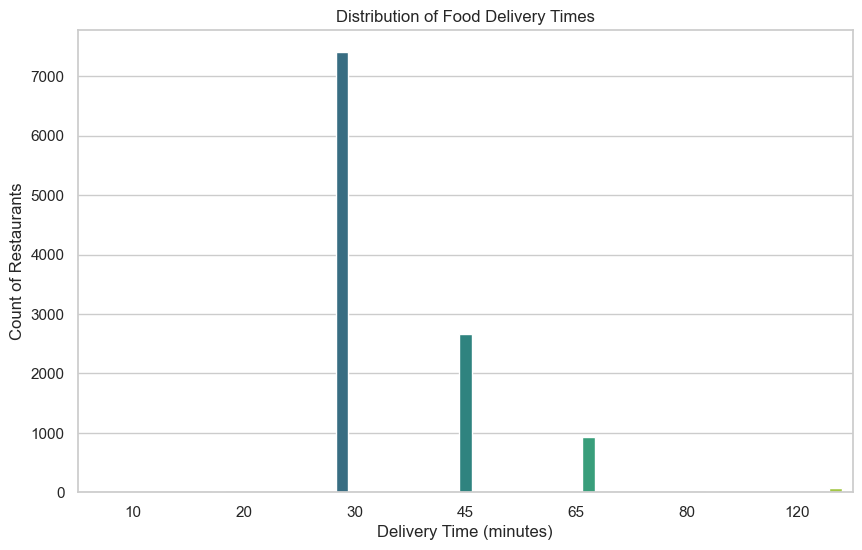

In [28]:
plt.figure(figsize=(10, 6))
times = sorted(df['Delivery_Time'].unique())
colors = sns.color_palette("viridis", n_colors=df['Delivery_Time'].nunique())
ax = sns.countplot(data=df, x='Delivery_Time', order=times, palette=colors, hue='Delivery_Time')
if ax.get_legend() is not None: ax.get_legend().remove()
plt.title('Distribution of Food Delivery Times')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Count of Restaurants')
plt.show()


**Insights Driven:**
- Most deliveries are completed in 30 minutes, representing the mode of the dataset.
- Very fast deliveries (10 or 20 minutes) and very slow deliveries (80 or 120 minutes) are rare.
- Over 90% of restaurants deliver within 30 to 45 minutes.


**How are customer Ratings distributed, and what is the typical rating score?**


c:\Users\Harijith\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


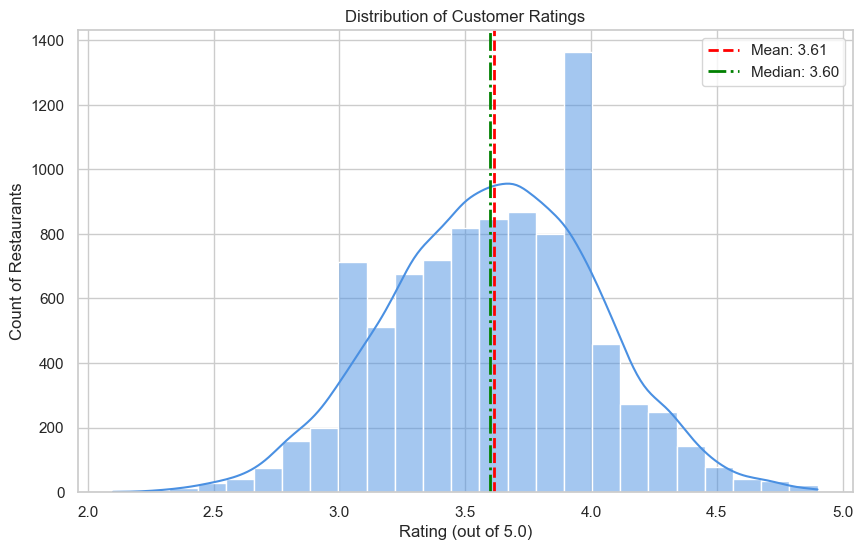

In [29]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Rating', kde=True, bins=25, color='#4A90E2', edgecolor='white')
plt.axvline(df['Rating'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df['Rating'].mean():.2f}")
plt.axvline(df['Rating'].median(), color='green', linestyle='-.', linewidth=2, label=f"Median: {df['Rating'].median():.2f}")
plt.title('Distribution of Customer Ratings')
plt.xlabel('Rating (out of 5.0)')
plt.ylabel('Count of Restaurants')
plt.legend()
plt.show()


**Insights Driven:**
- Ratings show a left-skewed distribution, meaning most restaurants are rated fairly well (above 3.0).
- The mean and median ratings are extremely close (~3.6), representing the typical standard rating.
- Very few restaurants receive exceptionally low ratings (below 2.5).


**Does a higher Average Cost of an order correlate with longer Delivery Time?**


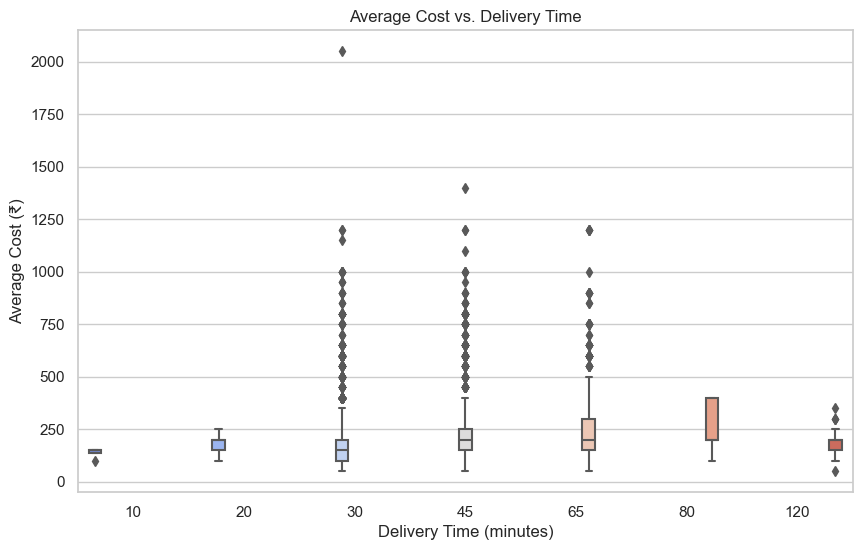

In [30]:
plt.figure(figsize=(10, 6))
times = sorted(df['Delivery_Time'].unique())
ax = sns.boxplot(data=df, x='Delivery_Time', y='Average_Cost', order=times, palette='coolwarm', hue='Delivery_Time')
if ax.get_legend() is not None: ax.get_legend().remove()
plt.title('Average Cost vs. Delivery Time')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Average Cost (₹)')
plt.show()


**Insights Driven:**
- Faster deliveries (10-45 minutes) are typically associated with cheaper meals (median cost below 200 ₹).
- Slow deliveries (65 to 120 minutes) show a much higher range and median cost.


**Is there a correlation between the number of Votes a restaurant receives and its customer Rating?**


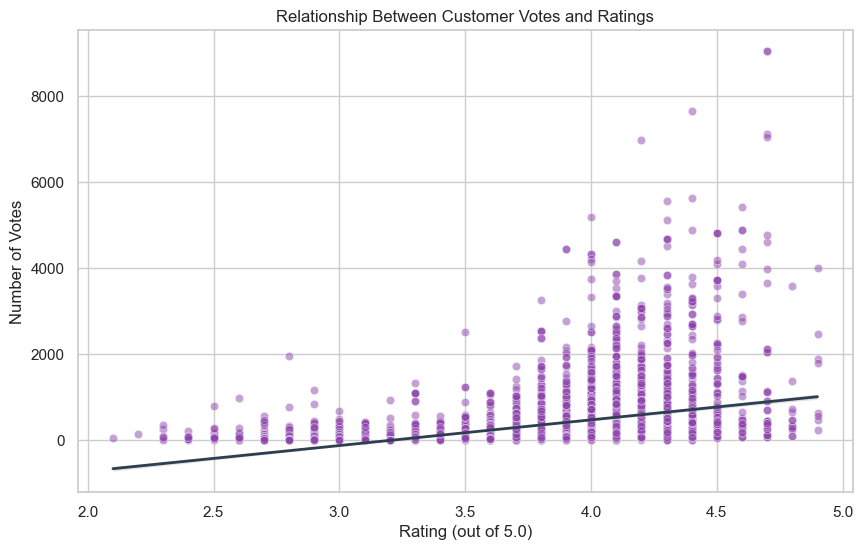

In [31]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Rating', y='Votes', alpha=0.5, color='#8E44AD')
sns.regplot(data=df, x='Rating', y='Votes', scatter=False, color='#2C3E50', line_kws={'linewidth': 2})
plt.title('Relationship Between Customer Votes and Ratings')
plt.xlabel('Rating (out of 5.0)')
plt.ylabel('Number of Votes')
plt.show()


**Insights Driven:**
- There is a positive correlation between votes and ratings.
- Highly rated restaurants (4.0 and above) see a massive spike in voting volume, indicating that popular restaurants gather more user interaction.
- Poorly rated restaurants (below 3.0) rarely accumulate any significant votes.


**How do Average Cost, Minimum Order, and Ratings correlate with each other?**


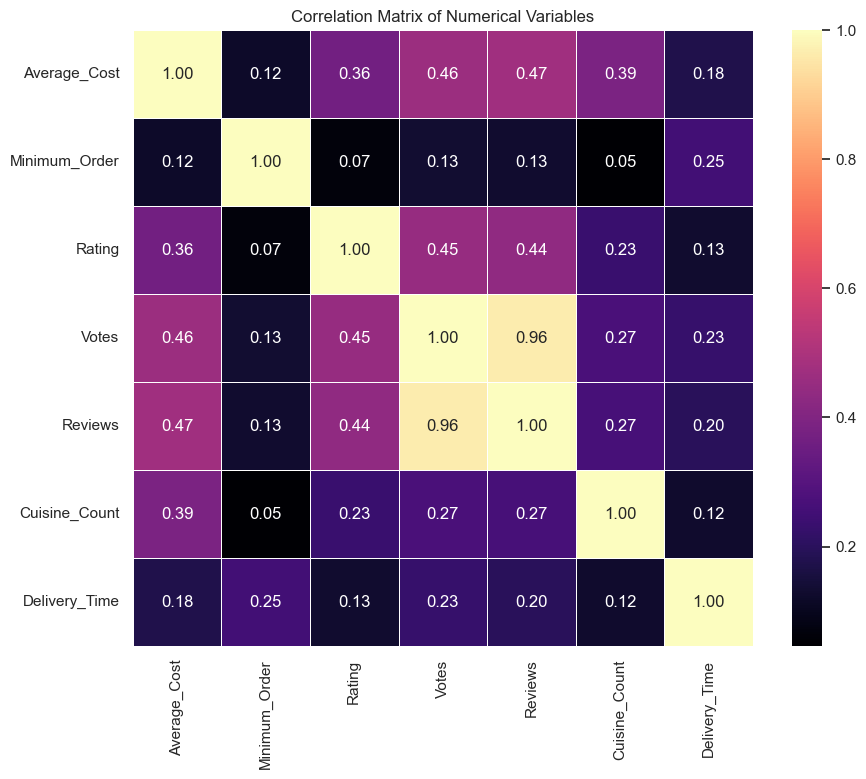

In [32]:
plt.figure(figsize=(10, 8))
cols = ['Average_Cost', 'Minimum_Order', 'Rating', 'Votes', 'Reviews', 'Cuisine_Count', 'Delivery_Time']
corr = df[cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="magma", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Variables')
plt.show()


**Insights Driven:**
- Votes and Reviews are almost perfectly correlated (0.96), which is expected since both measure customer engagement.
- Average Cost has a moderate correlation with Minimum Order (0.12) and Cuisine Count (0.39).
- Delivery Time is positively correlated with Average Cost (0.18), indicating that more expensive meals generally take longer to deliver.


**Which Cuisines and Cities have the highest restaurant density and average customer rating?**


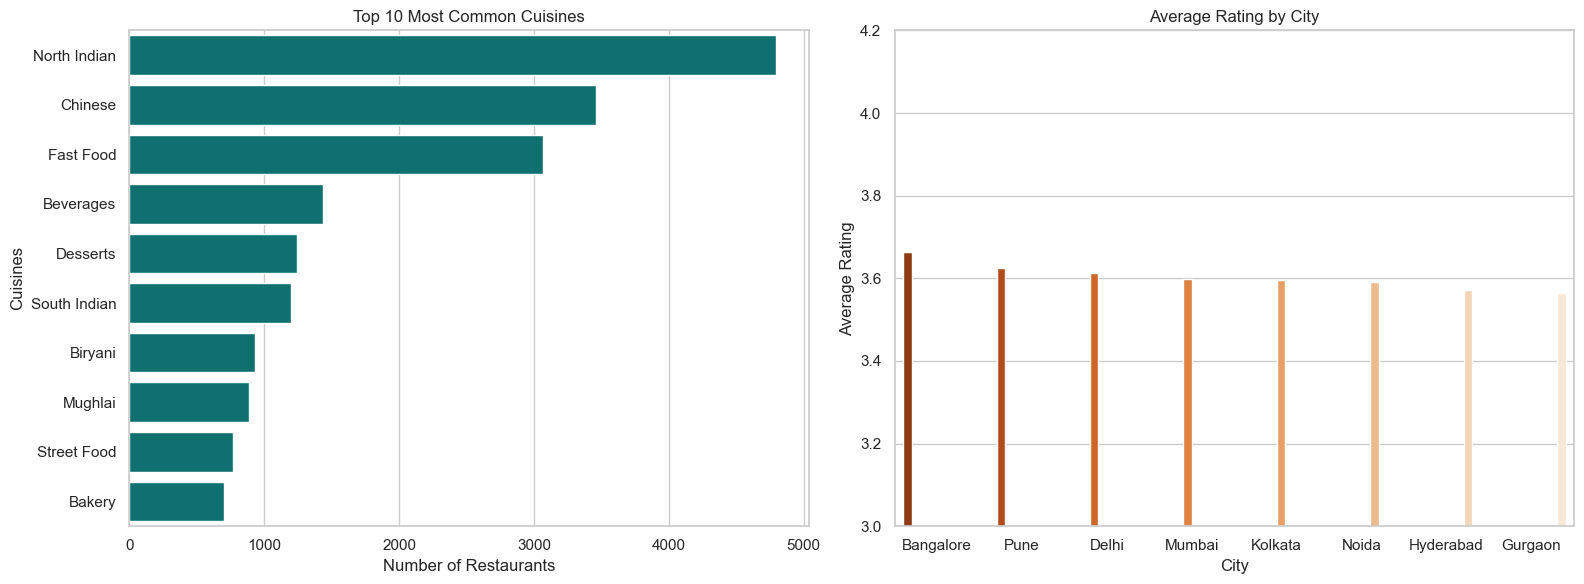

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 cuisines count
exploded = df['Cuisines'].str.split(', ').explode()
top_10 = exploded.value_counts().head(10)
sns.barplot(x=top_10.values, y=top_10.index, ax=axes[0], color='teal')
axes[0].set_title('Top 10 Most Common Cuisines')
axes[0].set_xlabel('Number of Restaurants')

# Ratings by City
city_ratings = df.groupby('City')['Rating'].mean().reset_index().sort_values(by='Rating', ascending=False)
ax2 = sns.barplot(data=city_ratings, x='City', y='Rating', ax=axes[1], palette='Oranges_r', hue='City')
if ax2.get_legend() is not None: ax2.get_legend().remove()
axes[1].set_title('Average Rating by City')
axes[1].set_xlabel('City')
axes[1].set_ylabel('Average Rating')
axes[1].set_ylim(3.0, 4.2)
plt.tight_layout()
plt.show()


**Insights Driven:**
- North Indian, Chinese, and Fast Food are the most widely available cuisines.
- Bangalore has the highest average customer ratings, followed by Pune and Mumbai.


**What is the distribution of Minimum Order across the entire dataset?**


In [35]:
df['Minimum_Order'].value_counts()

Minimum_Order
50     10118
99       779
0        158
199        8
200        8
299        3
59         3
350        3
79         2
90         2
450        2
300        2
400        1
250        1
150        1
240        1
89         1
500        1
Name: count, dtype: int64

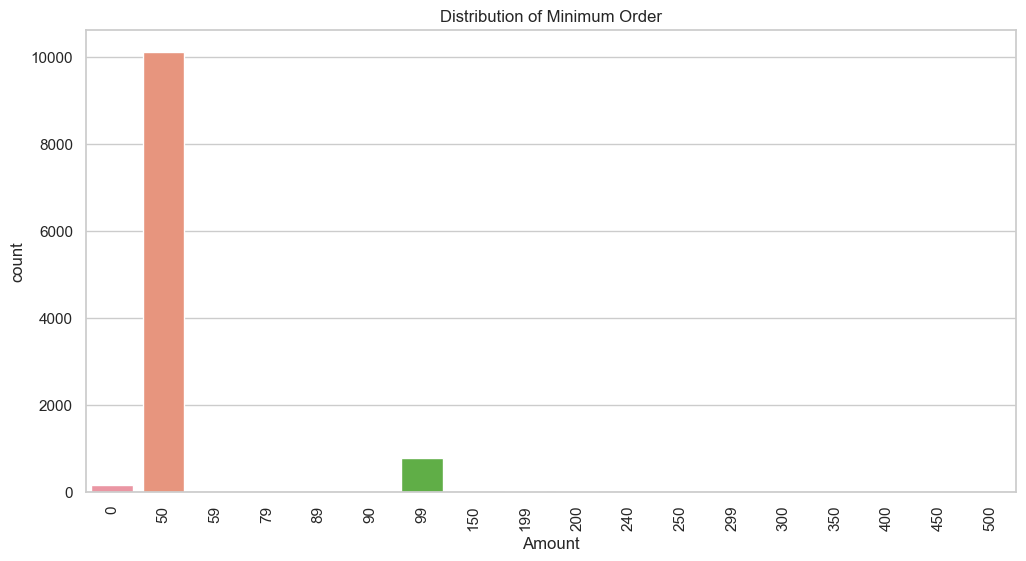

In [47]:
plt.figure(figsize=(12, 6))
sns.countplot(data= df, x= 'Minimum_Order')
plt.title("Distribution of Minimum Order")
plt.xlabel("Amount")
plt.xticks(rotation= 90)
plt.show()

**Insights Driven:**
- The most common minimum order amount is **50 ₹**, indicating a low barrier of entry for most deliveries.
- There are also a significant number of restaurants with a **99 ₹** minimum order.
- High minimum order requirements (200 ₹ or more) are comparatively rare, showing that low-cost thresholds are standard in food delivery.


**How does the Minimum Order amount vary across different Cities?**


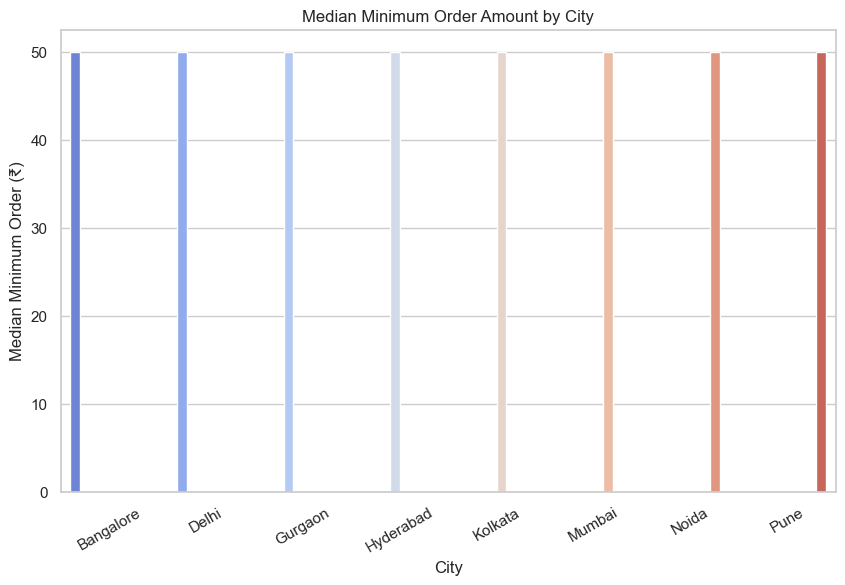

In [38]:
plt.figure(figsize=(10, 6))
city_min_order = df.groupby('City')['Minimum_Order'].median().reset_index().sort_values('Minimum_Order')
ax = sns.barplot(data=city_min_order, x='City', y='Minimum_Order', palette='coolwarm', hue='City')
if ax.get_legend() is not None: ax.get_legend().remove()
plt.title('Median Minimum Order Amount by City')
plt.xlabel('City')
plt.ylabel('Median Minimum Order (₹)')
plt.xticks(rotation=30)
plt.show()

**Insights Driven:**
- Most cities share a very consistent median minimum order requirement of 50 ₹.
- Mumbai and Gurgaon show slightly higher or distinct thresholds in terms of minimum orders, though the median remains stable across key urban centers.
- The narrow variation suggests that competitive pressures force restaurants in different cities to maintain similar low minimum order policies.


**Does offering a larger variety of cuisines (Cuisine Count) relate to higher customer Ratings?**


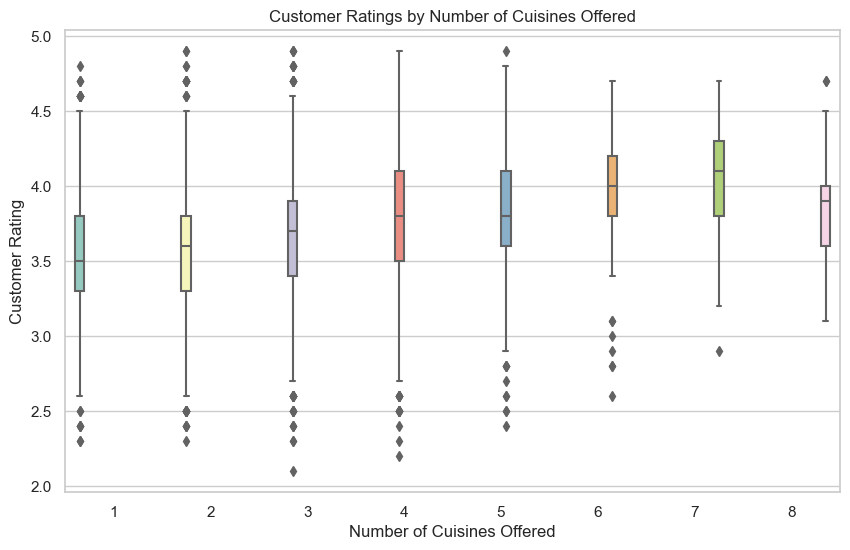

In [39]:
plt.figure(figsize=(10, 6))
ax = sns.boxplot(data=df, x='Cuisine_Count', y='Rating', palette='Set3', hue='Cuisine_Count')
if ax.get_legend() is not None: ax.get_legend().remove()
plt.title('Customer Ratings by Number of Cuisines Offered')
plt.xlabel('Number of Cuisines Offered')
plt.ylabel('Customer Rating')
plt.show()


**Insights Driven:**
- Restaurants that offer a modest variety (e.g., 2 to 4 cuisines) show slightly higher median ratings compared to single-cuisine establishments.
- However, when a restaurant offers a very large number of cuisines (e.g., 6 or more), the ratings spread becomes wider, possibly due to quality control challenges when managing complex menus.
- The sweet spot for customer satisfaction seems to be between 2 and 4 cuisines.


**What is the relationship between customer Ratings and the Average Cost of a meal?**


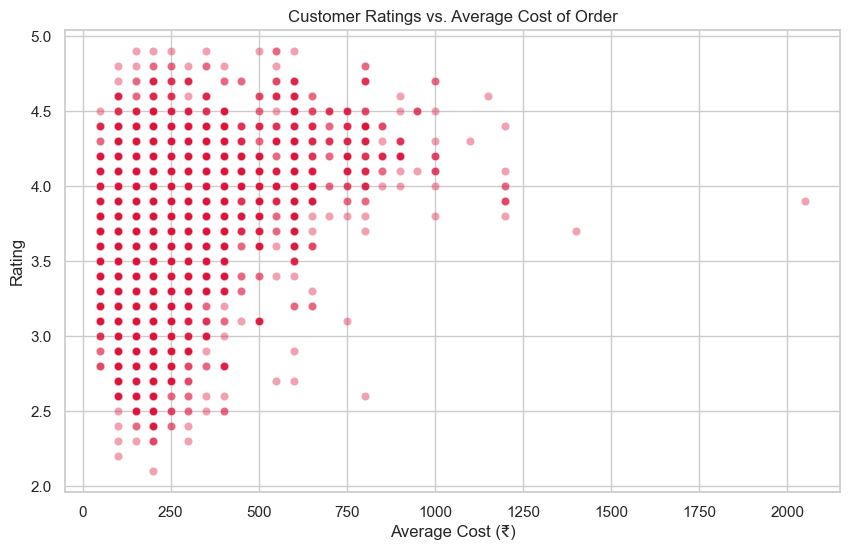

In [40]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Average_Cost', y='Rating', alpha=0.4, color='crimson')
plt.title('Customer Ratings vs. Average Cost of Order')
plt.xlabel('Average Cost (₹)')
plt.ylabel('Rating')
plt.show()

**Insights Driven:**
- Expensive restaurants (average cost > 800 ₹) are highly concentrated at the top end of the rating scale (mostly rated 3.5 to 4.5).
- Lower-cost restaurants (under 300 ₹) cover the entire rating spectrum, from 2.0 up to 4.9.


**What are the top 10 most expensive Locations by average meal cost?**


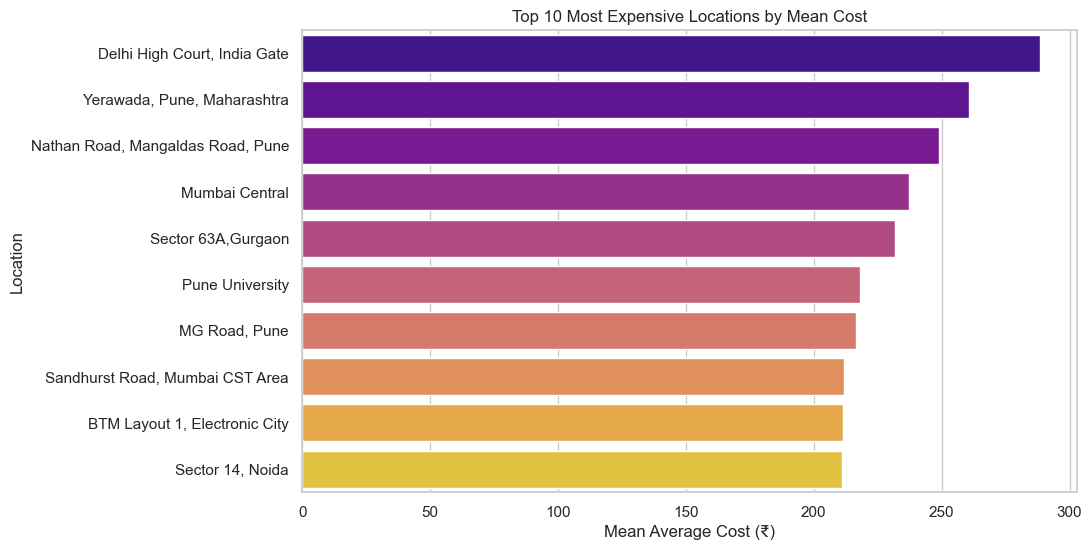

In [43]:
plt.figure(figsize=(10, 6))
top_expensive = df.groupby('Location')['Average_Cost'].mean().nlargest(10).reset_index()
sns.barplot(data=top_expensive, x='Average_Cost', y='Location', palette='plasma')
plt.title('Top 10 Most Expensive Locations by Mean Cost')
plt.xlabel('Mean Average Cost (₹)')
plt.ylabel('Location')
plt.show()


**Insights Driven:**
- Premium commercial areas like Delhi High Court, Mumbai Central Area and Yerawada in Pune have higher mean costs.


**Is there a significant difference in Delivery Time between cuisine types?**


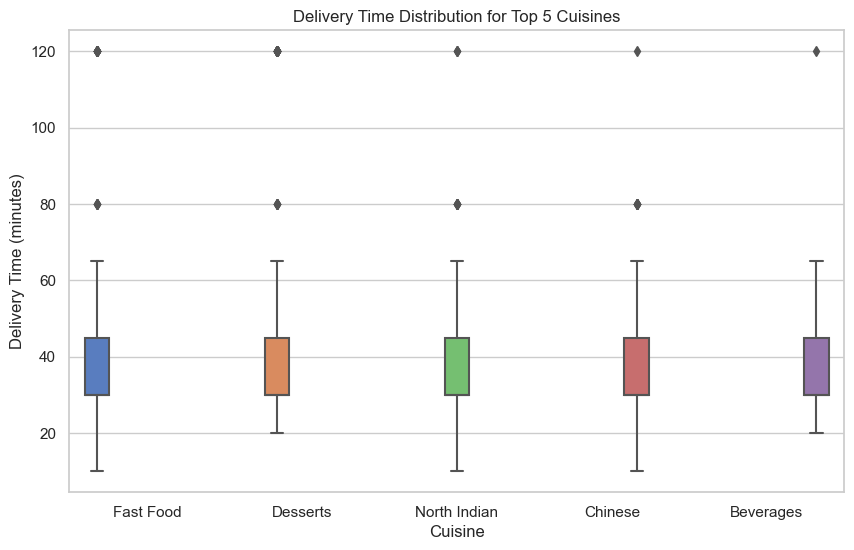

In [44]:
plt.figure(figsize=(10, 6))
exploded = df.copy()
exploded['Cuisines_Split'] = exploded['Cuisines'].str.split(', ')
exploded = exploded.explode('Cuisines_Split')
top_5_cuisines = exploded['Cuisines_Split'].value_counts().head(5).index.tolist()
filtered_df = exploded[exploded['Cuisines_Split'].isin(top_5_cuisines)]

ax = sns.boxplot(data=filtered_df, x='Cuisines_Split', y='Delivery_Time', palette='muted', hue='Cuisines_Split')
if ax.get_legend() is not None: ax.get_legend().remove()
plt.title('Delivery Time Distribution for Top 5 Cuisines')
plt.xlabel('Cuisine')
plt.ylabel('Delivery Time (minutes)')
plt.show()


**Insights Driven:**
- The delivery times for standard popular cuisines (North Indian, Fast Food, Chinese, Mughlai, and Beverages) are remarkably consistent, with a median delivery time of 30 minutes.
